# 🍔 Food Calorie Detector — Vision Transformer (ViT-B/16)

This notebook trains a **Vision Transformer (ViT-B/16)** model to:
1. Classify food images into 63 categories
2. Map each predicted class to an estimated calorie range

**Pipeline overview:**
- Mount Google Drive & unzip the dataset
- Build train / val / test splits
- Fine-tune ViT-B/16 (ImageNet-21k pretrained)
- Evaluate & visualize results
- Run inference with calorie lookup on a new image

**Expected files in your Google Drive (root):**
- `final_matched_dataset.csv`
- `dataset (6).zip`

## 1 — Install & Import

In [ ]:
!pip install -q torch torchvision timm matplotlib seaborn scikit-learn Pillow tqdm

In [ ]:
import os, zipfile, random, json, math, copy
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import timm

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## 2 — Mount Google Drive & Set Up Paths

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

CSV_PATH = Path("/content/final_matched_dataset.csv")

ZIP_PATH = Path("/content/dataset (6).zip")

EXTRACT_DIR = Path("/content/food_dataset")

print("CSV exists:", CSV_PATH.exists())
print("ZIP exists:", ZIP_PATH.exists())

CSV exists: True
ZIP exists: True


In [ ]:
# ── Unzip the image dataset (only once per session) ───────────────────────────
if not EXTRACT_DIR.exists():
    print('Extracting zip … (this may take a minute)')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_DIR)
    print('Done!')
else:
    print('Already extracted — skipping.')

print('\nTop-level contents of extraction folder:')
for p in sorted(EXTRACT_DIR.iterdir()):
    print(' ', p)

Extracting zip … (this may take a minute)
Done!

Top-level contents of extraction folder:
  /content/food_dataset/dataset


In [ ]:
# ── Auto-detect DATA_ROOT (handles zip extracting into a subfolder or not) ────
def find_data_root(base: Path) -> Path:
    """Return the folder whose immediate children are the class directories."""
    candidates = [base] + [p for p in base.iterdir() if p.is_dir()]
    for c in candidates:
        subdirs = [d for d in c.iterdir() if d.is_dir()]
        if len(subdirs) >= 5:
            return c
    raise RuntimeError(
        f'Cannot find class folders under {base}. '
        'Please check the zip structure manually.'
    )

DATA_ROOT = find_data_root(EXTRACT_DIR)
print(f'DATA_ROOT: {DATA_ROOT}')

classes = sorted([d.name for d in DATA_ROOT.iterdir() if d.is_dir()])
print(f'Found {len(classes)} classes:')
print(classes)

DATA_ROOT: /content/food_dataset/dataset
Found 64 classes:
['apple', 'bakery', 'banana', 'beef', 'bread', 'breakfast', 'broccoli', 'burger', 'burrito', 'butter', 'cake', 'carrot', 'cheese', 'chicken', 'chips', 'chocolate', 'coffee', 'cookies', 'corn', 'cream', 'cucumber', 'duck', 'falafel', 'fish', 'fried_chicken', 'garlic', 'grape', 'hummus', 'ice_cream', 'juice', 'kebab', 'lamb', 'lasagna', 'lettuce', 'mango', 'milk', 'noodles', 'oats', 'onion', 'orange', 'pasta', 'pineapple', 'pizza', 'popcorn', 'potato', 'quinoa', 'rice', 'salad', 'salmon', 'sandwich', 'shawarma', 'shrimp', 'smoothie', 'spinach', 'strawberry', 'sushi', 'sweet_potato', 'taco', 'tea', 'tomato', 'tuna', 'turkey', 'watermelon', 'yogurt']


## 3 — Dataset Exploration

Total images: 18120


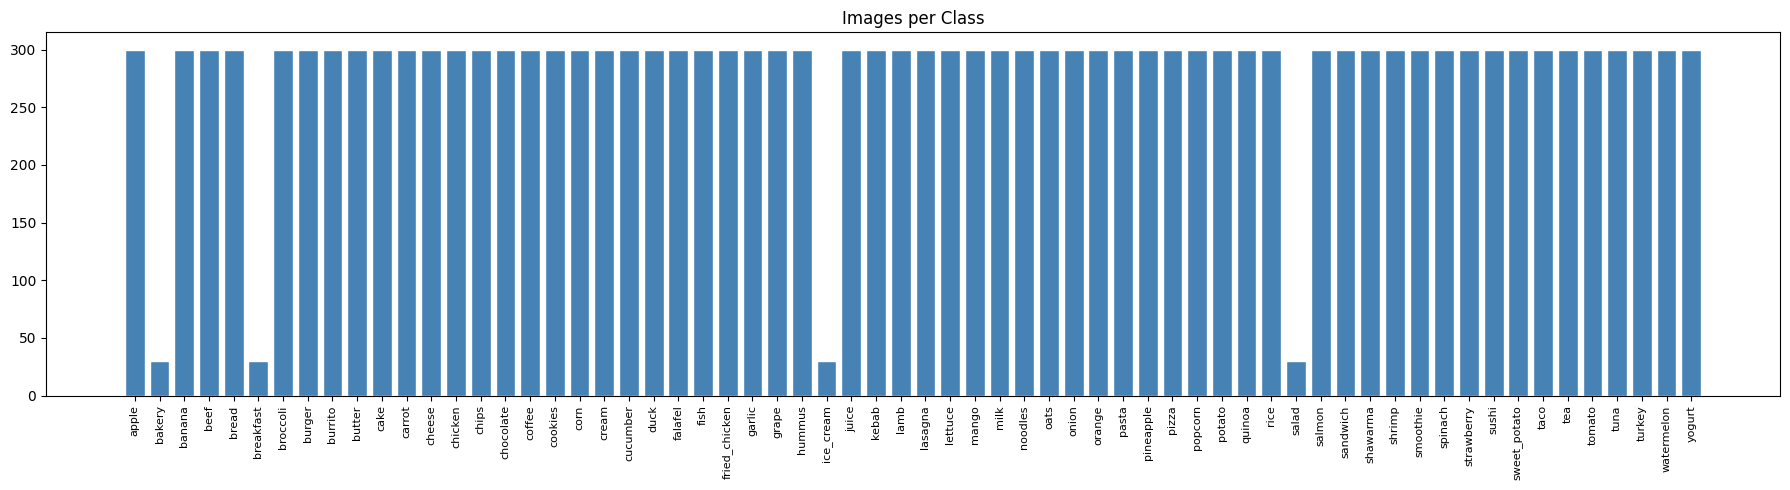

In [ ]:
counts = {cls: len(list((DATA_ROOT / cls).glob('*.*'))) for cls in classes}
total  = sum(counts.values())
print(f'Total images: {total}')

plt.figure(figsize=(18, 5))
plt.bar(counts.keys(), counts.values(), color='steelblue', edgecolor='white')
plt.xticks(rotation=90, fontsize=8)
plt.title('Images per Class')
plt.tight_layout()
plt.show()

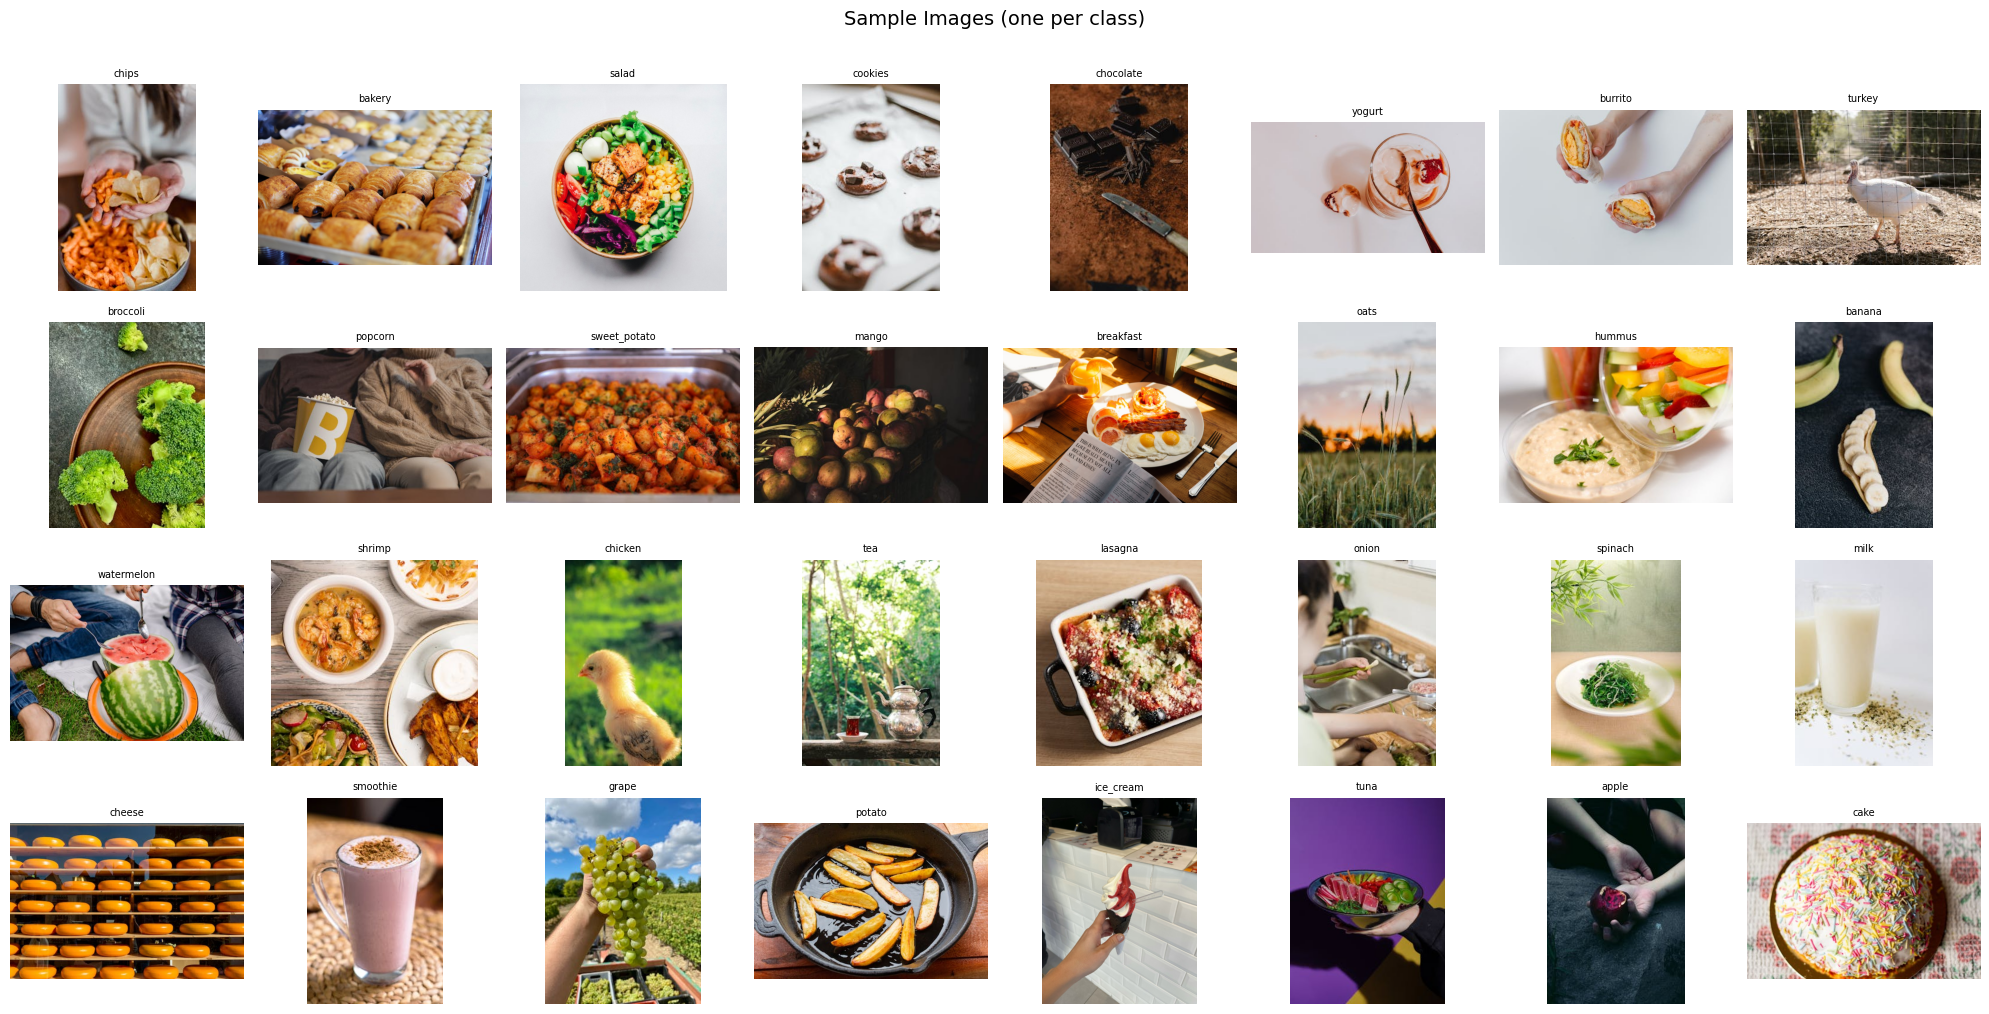

In [ ]:
fig, axes = plt.subplots(4, 8, figsize=(20, 10))
sample_classes = random.sample(classes, min(32, len(classes)))
for ax, cls in zip(axes.flat, sample_classes):
    imgs = list((DATA_ROOT / cls).glob('*.*'))
    if imgs:
        img = Image.open(random.choice(imgs)).convert('RGB')
        ax.imshow(img)
    ax.set_title(cls, fontsize=7)
    ax.axis('off')
plt.suptitle('Sample Images (one per class)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4 — Calorie Lookup Table

Calories per **100 g** (approximate).  
The model predicts the class → we look up the calorie estimate from the CSV.

In [ ]:
import pandas as pd

df_cal = pd.read_csv(CSV_PATH)
print('CSV shape:', df_cal.shape)
df_cal.head()

CSV shape: (13829, 9)


,name,matched_name,ingredients,category,portion,calories,protein,fat,carb
0,chicken handi,chicken,"Chicken, Onion, Tomatoes, Garlic, Ginger paste...",meat,100 g,166.0,21.4,1.79,0.0
1,chicken mandi,chicken,"Chicken, Basmati Rice, Water, Onion, Garlic, G...",meat,100 g,166.0,21.4,1.79,0.0
2,sticky chicken,chicken,"Chicken drumsticks, Soy Sauce, Honey, Olive Oi...",meat,100 g,166.0,21.4,1.79,0.0
3,chicken congee,chicken,"Chicken, Salt, Pepper, Ginger Cordial, Ginger,...",meat,100 g,166.0,21.4,1.79,0.0
4,chicken karaage,chicken,"Chicken, Ginger, Garlic, Soy sauce, Sake, Gran...",meat,100 g,166.0,21.4,1.79,0.0


In [ ]:
CLASS_TO_CSV = {
    'apple':         'apple',
    'bakery':        'white bread',
    'banana':        'banana',
    'beef':          'beef',
    'bread':         'white bread',
    'breakfast':     'oats',
    'broccoli':      'broccoli',
    'burger':        'hamburger',
    'burrito':       'burrito',
    'butter':        'butter',
    'cake':          'yellow cake',
    'carrot':        'carrot',
    'cheese':        'cheddar cheese',
    'chicken':       'chicken',
    'chips':         'baked chips',
    'chocolate':     'chocolate bar',
    'coffee':        'coffee creamer',
    'cookies':       'cookies',
    'corn':          'corn',
    'cream':         'cream',
    'cucumber':      'cucumber',
    'duck':          'duck',
    'falafel':       'falafel',
    'fish':          'white fish',
    'fried_chicken': 'chicken breast fried',
    'garlic':        'garlic',
    'grape':         'grapes',
    'hummus':        'hummus',
    'ice_cream':     'vanilla ice cream',
    'juice':         'mango',
    'kebab':         'kebab',
    'lamb':          'lamb',
    'lasagna':       'lasagna',
    'lettuce':       'romaine lettuce',
    'mango':         'mango',
    'milk':          'oat milk',
    'noodles':       'egg noodles cooked',
    'oats':          'oats',
    'onion':         'onion',
    'orange':        'orange',
    'pasta':         'pasta',
    'pineapple':     'pineapple',
    'pizza':         'margherita pizza',
    'popcorn':       'popcorn air popped',
    'potato':        'white potato',
    'quinoa':        'quinoa',
    'rice':          'white rice cooked',
    'salad':         'mixed greens salad',
    'salmon':        'salmon',
    'sandwich':      'sandwich',
    'shawarma':      'kebab',
    'shrimp':        'shrimp',
    'smoothie':      'banana',
    'spinach':       'spinach',
    'strawberry':    'strawberries',
    'sushi':         'tuna sushi maki',
    'sweet_potato':  'sweet potato',
    'taco':          'taco',
    'tea':           'tea',
    'tomato':        'tomato',
    'tuna':          'tuna',
    'turkey':        'turkey',
    'watermelon':    'melon water melon',
    'yogurt':        'greek yogurt',
}


def build_calorie_table(df: pd.DataFrame, class_to_csv: dict) -> dict:
    table = {}
    for cls, csv_name in class_to_csv.items():
        rows = df[df['matched_name'] == csv_name]
        if rows.empty:
            print(f'⚠️ Missing in CSV: {csv_name} (class: {cls}) → set 0')
            table[cls] = 0
        else:
            table[cls] = round(rows['calories'].mean(), 1)
    return table


CALORIE_TABLE = build_calorie_table(df_cal, CLASS_TO_CSV)

missing = [c for c in classes if c not in CALORIE_TABLE]
if missing:
    print('Missing calorie entries:', missing)
else:
    print('✅ All classes have calorie entries!')

print('\nSample values:')
for cls in list(CALORIE_TABLE)[:6]:
    print(f'  {cls}: {CALORIE_TABLE[cls]} kcal / 100g')

✅ All classes have calorie entries!

Sample values:
  apple: 64.0 kcal / 100g
  bakery: 246.0 kcal / 100g
  banana: 92.0 kcal / 100g
  beef: 156.0 kcal / 100g
  bread: 246.0 kcal / 100g
  breakfast: 349.0 kcal / 100g


## 5 — Data Transforms & Splits

**ViT-specific notes:**
- ViT-B/16 expects **224×224** patches (16×16 px each → 14×14 = 196 patches).
- **RandAugment** is added because ViT has no convolutional inductive bias and is more data-hungry.
- Normalization uses the same ImageNet mean/std as during ViT pretraining.

In [ ]:
IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_WORKERS = 2

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.2, hue=0.05),
    transforms.RandomRotation(15),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

full_dataset = datasets.ImageFolder(str(DATA_ROOT), transform=train_tf)
NUM_CLASSES  = len(full_dataset.classes)
print(f'Classes ({NUM_CLASSES}): {full_dataset.classes}')

Classes (64): ['apple', 'bakery', 'banana', 'beef', 'bread', 'breakfast', 'broccoli', 'burger', 'burrito', 'butter', 'cake', 'carrot', 'cheese', 'chicken', 'chips', 'chocolate', 'coffee', 'cookies', 'corn', 'cream', 'cucumber', 'duck', 'falafel', 'fish', 'fried_chicken', 'garlic', 'grape', 'hummus', 'ice_cream', 'juice', 'kebab', 'lamb', 'lasagna', 'lettuce', 'mango', 'milk', 'noodles', 'oats', 'onion', 'orange', 'pasta', 'pineapple', 'pizza', 'popcorn', 'potato', 'quinoa', 'rice', 'salad', 'salmon', 'sandwich', 'shawarma', 'shrimp', 'smoothie', 'spinach', 'strawberry', 'sushi', 'sweet_potato', 'taco', 'tea', 'tomato', 'tuna', 'turkey', 'watermelon', 'yogurt']


In [ ]:
# Stratified 70 / 15 / 15 split
targets = np.array(full_dataset.targets)
indices = np.arange(len(targets))

train_idx, tmp_idx = train_test_split(
    indices, test_size=0.30, stratify=targets, random_state=SEED)
val_idx, test_idx = train_test_split(
    tmp_idx, test_size=0.50,
    stratify=targets[tmp_idx], random_state=SEED)

print(f'Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}')

train_set = Subset(full_dataset, train_idx)

val_ds   = datasets.ImageFolder(str(DATA_ROOT), transform=val_tf)
val_set  = Subset(val_ds, val_idx)
test_set = Subset(val_ds, test_idx)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

CLASS_NAMES = full_dataset.classes

Train: 12684 | Val: 2718 | Test: 2718


## 6 — Build Model (ViT-B/16)

Using `vit_base_patch16_224.augreg21k_ft_in1k` from `timm`:
- Pretrained on **ImageNet-21k** then fine-tuned on **ImageNet-1k**
- 12 transformer layers, 768-dim hidden size, 12 attention heads
- The classification head (`model.head`) is replaced for our 63-class food task

**Two-phase training:**
1. Freeze all transformer blocks → train only the new head
2. Unfreeze everything → fine-tune end-to-end at a small LR

In [ ]:
def build_model(num_classes: int, freeze_backbone: bool = True):
    model = timm.create_model(
        'vit_base_patch16_224.augreg_in21k_ft_in1k', # Corrected pretrained tag
        pretrained=True,
        num_classes=num_classes
    )
    if freeze_backbone:
        for name, param in model.named_parameters():
            if 'head' not in name:
                param.requires_grad = False
    return model


model = build_model(NUM_CLASSES, freeze_backbone=True).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_p   = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total_p:,}')
print(f'Head: {model.head}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Trainable params: 49,216 / 85,847,872
Head: Linear(in_features=768, out_features=64, bias=True)


## 7 — Training

In [ ]:
EPOCHS_HEAD  = 5
EPOCHS_FULL  = 15
LR_HEAD      = 3e-4   # slightly higher — ViT head is a single Linear
LR_FULL      = 1e-5   # lower — attention weights are sensitive
WEIGHT_DECAY = 1e-4
LABEL_SMOOTH = 0.1

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD, weight_decay=WEIGHT_DECAY
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_HEAD)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
best_weights = None


def run_epoch(loader, training=True):
    model.train(training)
    total_loss, correct, n = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, labels in tqdm(loader, leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if training:
                optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, labels)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(labels)
            correct    += (logits.argmax(1) == labels).sum().item()
            n          += len(labels)
    return total_loss / n, correct / n


def train_phase(n_epochs, phase_name):
    global best_val_acc, best_weights
    print(f'\n{"="*55}')
    print(f'  Phase: {phase_name}  |  Epochs: {n_epochs}')
    print(f'{"="*55}')
    for epoch in range(1, n_epochs + 1):
        tr_loss, tr_acc = run_epoch(train_loader, training=True)
        vl_loss, vl_acc = run_epoch(val_loader,   training=False)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        flag = ''
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_weights = copy.deepcopy(model.state_dict())
            flag = '  ← best'

        print(f'Epoch {epoch:02d}/{n_epochs} | '
              f'loss {tr_loss:.4f}/{vl_loss:.4f} | '
              f'acc {tr_acc*100:.1f}%/{vl_acc*100:.1f}%{flag}')

In [ ]:
# Phase 1: head only
train_phase(EPOCHS_HEAD, 'Head only (ViT frozen)')

# Phase 2: unfreeze & fine-tune
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(model.parameters(), lr=LR_FULL, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_FULL)

train_phase(EPOCHS_FULL, 'Full fine-tune (all ViT layers)')

model.load_state_dict(best_weights)
print(f'\n✅  Best val accuracy: {best_val_acc*100:.2f}%')


  Phase: Head only (ViT frozen)  |  Epochs: 5


  0%|          | 0/397 [00:00<?, ?it/s]

  0%|          | 0/85 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 01/5 | loss 2.7277/1.7865 | acc 44.6%/69.0%  ← best


...

  0%|          | 0/85 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 05/15 | loss 0.9638/1.1927 | acc 95.0%/87.3%  ← best


  0%|          | 0/397 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
torch.save(best_weights, "best_vit_model.pth")

## 8 — Training Curves

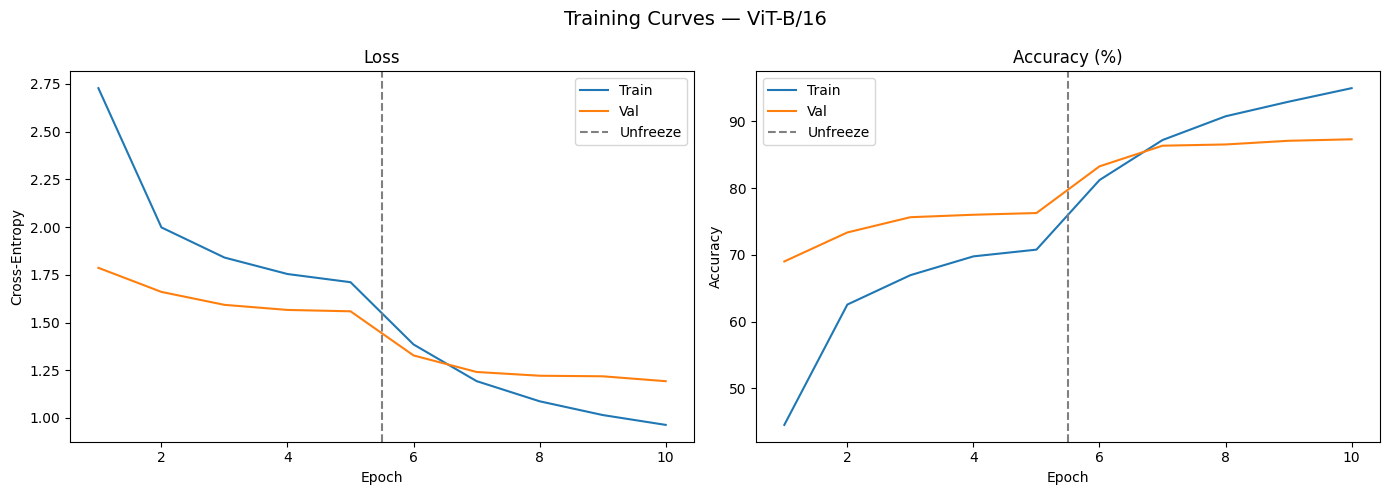

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, len(history['train_loss']) + 1)
phase_split = EPOCHS_HEAD

ax1.plot(epochs, history['train_loss'], label='Train')
ax1.plot(epochs, history['val_loss'],   label='Val')
ax1.axvline(phase_split + 0.5, color='gray', linestyle='--', label='Unfreeze')
ax1.set(title='Loss', xlabel='Epoch', ylabel='Cross-Entropy')
ax1.legend()

ax2.plot(epochs, [a*100 for a in history['train_acc']], label='Train')
ax2.plot(epochs, [a*100 for a in history['val_acc']],   label='Val')
ax2.axvline(phase_split + 0.5, color='gray', linestyle='--', label='Unfreeze')
ax2.set(title='Accuracy (%)', xlabel='Epoch', ylabel='Accuracy')
ax2.legend()

plt.suptitle('Training Curves — ViT-B/16', fontsize=14)
plt.tight_layout()
plt.show()

## 9 — Test-Set Evaluation

In [ ]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='Test'):
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean()
print(f'Test Accuracy: {test_acc*100:.2f}%\n')
print(classification_report(all_labels, all_preds,
                             target_names=CLASS_NAMES, digits=3))

Test:   0%|          | 0/85 [00:00<?, ?it/s]

Test Accuracy: 86.98%

               precision    recall  f1-score   support

        apple      1.000     0.978     0.989        45
       bakery      0.750     0.600     0.667         5
       banana      0.978     1.000     0.989        45
         beef      0.745     0.778     0.761        45
        bread      0.917     0.978     0.946        45
    breakfast      1.000     0.500     0.667         4
     broccoli      0.872     0.911     0.891        45
       burger      0.863     0.978     0.917        45
      burrito      0.577     0.667     0.619        45
       butter      0.714     0.778     0.745        45
         cake      0.957     0.978     0.967        45
       carrot      0.951     0.867     0.907        45
       cheese      1.000     0.933     0.966        45
      chicken      1.000     1.000     1.000        45
        chips      0.973     0.800     0.878        45
    chocolate      0.933     0.933     0.933        45
       coffee      0.936     0.978     0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


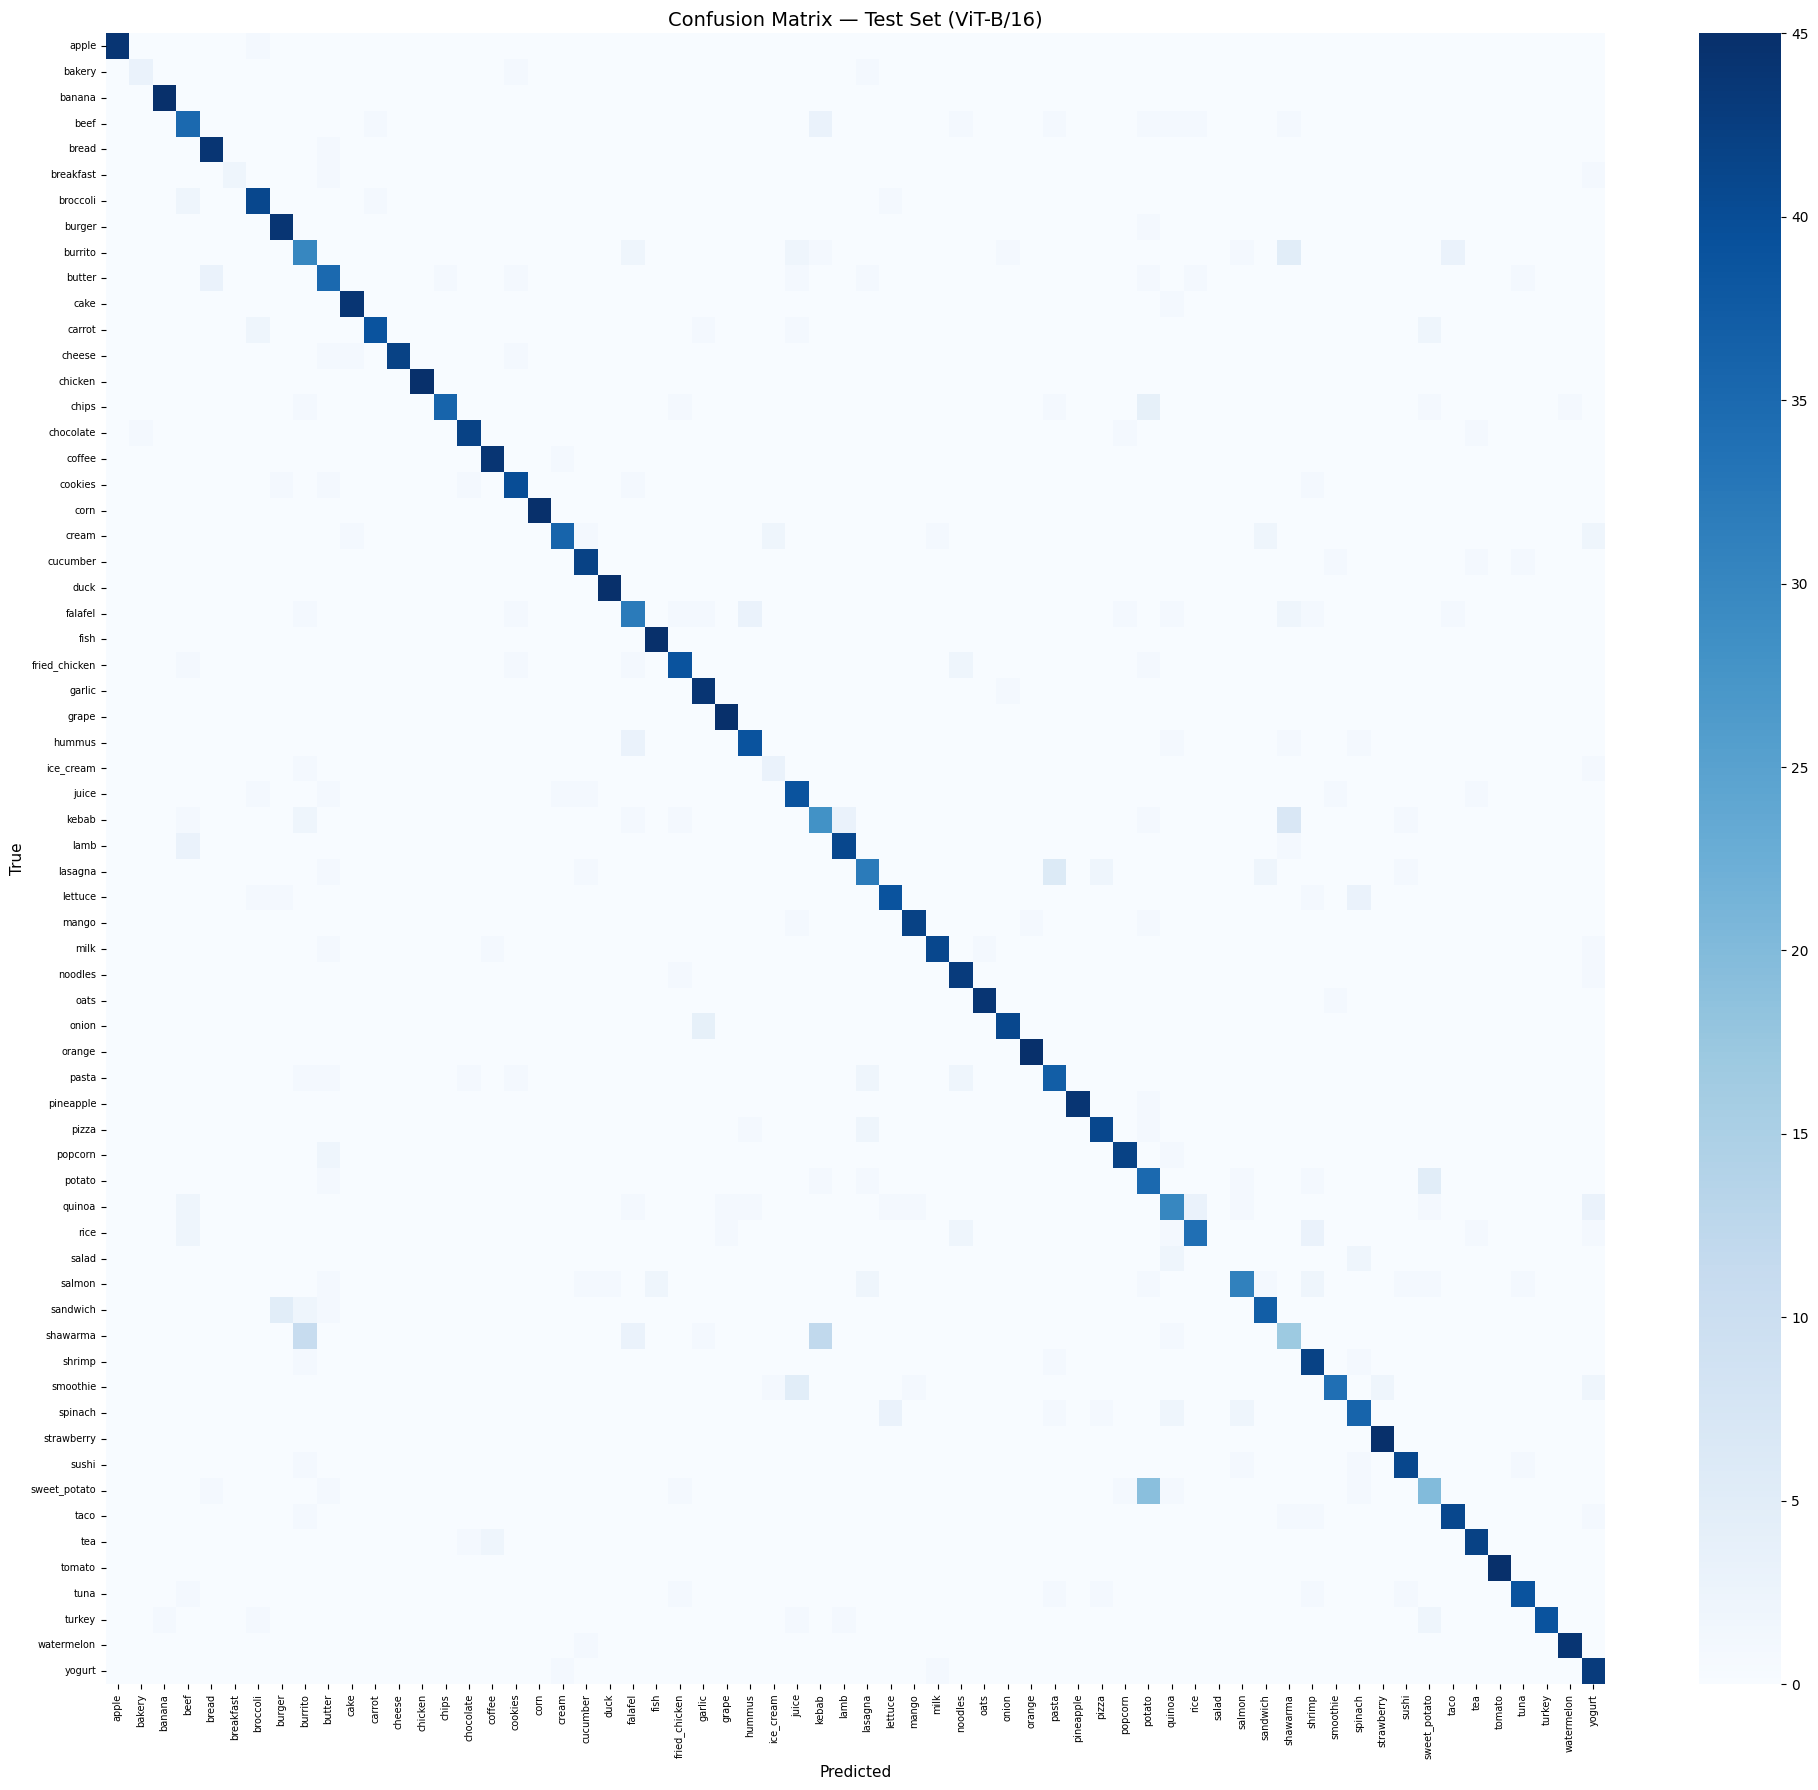

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(20, 18))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True',      fontsize=11)
ax.set_title('Confusion Matrix — Test Set (ViT-B/16)', fontsize=14)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.show()

## 10 — Visualise Attention Maps (ViT bonus)

ViT's self-attention weights show which patches the model focused on when predicting a class.

In [ ]:
def get_attention_map(model, img_tensor):

    model.eval()

    with torch.no_grad():

        outputs = model(
            img_tensor.unsqueeze(0).to(DEVICE),
            output_attentions=True
        )

    attentions = outputs.attentions

    rollout = torch.eye(attentions[0].shape[-1]).to(DEVICE)

    for attn in attentions:

        attn_heads_fused = attn.mean(dim=1)[0]

        attn_heads_fused += torch.eye(attn_heads_fused.shape[-1]).to(DEVICE)

        attn_heads_fused /= attn_heads_fused.sum(dim=-1, keepdim=True)

        rollout = torch.matmul(attn_heads_fused, rollout)

    mask = rollout[0, 1:]

    num_patches = int(mask.shape[0] ** 0.5)

    mask = mask.reshape(num_patches, num_patches).cpu().numpy()

    mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)

    return mask

## 11 — Inference with Calorie Estimation

In [ ]:
def predict_calories(image_path: str, top_k: int = 5, serving_g: int = 150):
    img    = Image.open(image_path).convert('RGB')
    tensor = val_tf(img).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1)[0]

    top_probs, top_idxs = probs.topk(top_k)
    top_probs = top_probs.cpu().numpy()
    top_idxs  = top_idxs.cpu().numpy()

    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 5))
    ax_img.imshow(img)
    ax_img.axis('off')
    ax_img.set_title(image_path, fontsize=9)

    labels = [CLASS_NAMES[i] for i in top_idxs]
    colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(top_k)]
    bars   = ax_bar.barh(labels[::-1], top_probs[::-1] * 100,
                          color=colors[::-1], edgecolor='white')
    ax_bar.set_xlabel('Confidence (%)')
    ax_bar.set_title(f'Top-{top_k} Predictions (ViT-B/16)')
    ax_bar.set_xlim(0, 100)

    for bar, prob in zip(bars[::-1], top_probs):
        ax_bar.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                    f'{prob*100:.1f}%', va='center', fontsize=9)

    best_class   = CLASS_NAMES[top_idxs[0]]
    confidence   = top_probs[0]
    csv_name     = CLASS_TO_CSV.get(best_class, best_class)
    cal_per_100g = CALORIE_TABLE.get(best_class, 0)
    cal_serving  = cal_per_100g * serving_g / 100

    info = (f'Predicted: {best_class.upper()}  ({confidence*100:.1f}%)\n'
            f'CSV entry: "{csv_name}" → {cal_per_100g} kcal / 100 g'
            f'  ≈  {cal_serving:.0f} kcal / {serving_g} g serving')
    ax_bar.set_xlabel(info, fontsize=10)

    plt.tight_layout()
    plt.show()

    return {
        'predicted_class':         best_class,
        'csv_matched_name':        csv_name,
        'confidence':              round(float(confidence), 4),
        'cal_per_100g':            cal_per_100g,
        f'cal_per_{serving_g}g':   round(cal_serving, 1),
        'top_k': [(CLASS_NAMES[i], round(float(p), 4))
                  for i, p in zip(top_idxs, top_probs)],
    }

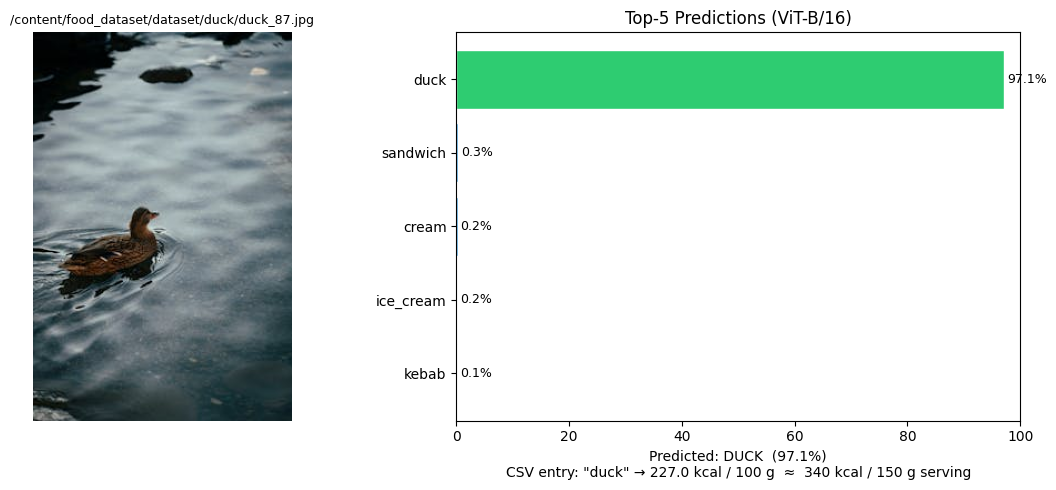

{
  "predicted_class": "duck",
  "csv_matched_name": "duck",
  "confidence": 0.9712,
  "cal_per_100g": 227.0,
  "cal_per_150g": 340.5,
  "top_k": [
    [
      "duck",
      0.9712
    ],
    [
      "sandwich",
      0.0033
    ],
    [
      "cream",
      0.0022
    ],
    [
      "ice_cream",
      0.0017
    ],
    [
      "kebab",
      0.0012
    ]
  ]
}



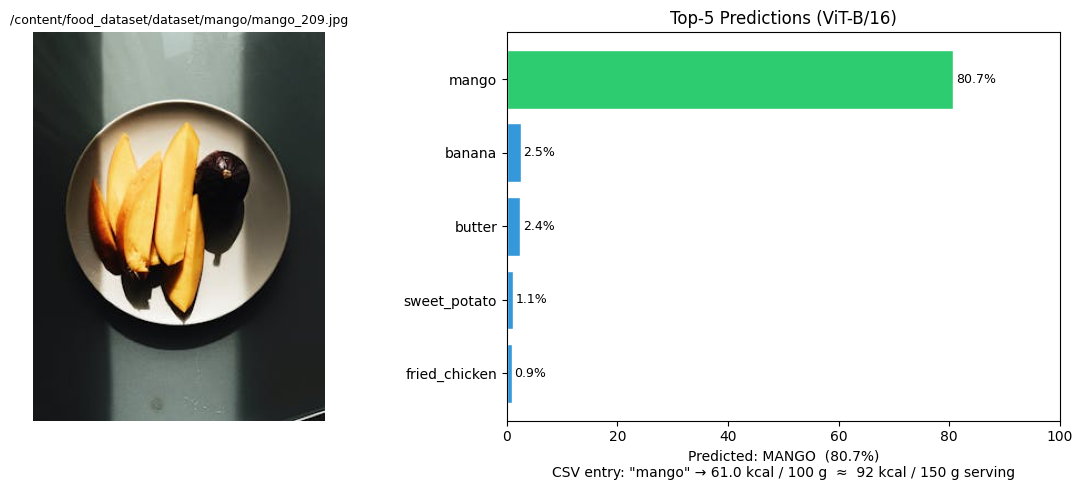

{
  "predicted_class": "mango",
  "csv_matched_name": "mango",
  "confidence": 0.8071,
  "cal_per_100g": 61.0,
  "cal_per_150g": 91.5,
  "top_k": [
    [
      "mango",
      0.8071
    ],
    [
      "banana",
      0.0251
    ],
    [
      "butter",
      0.024
    ],
    [
      "sweet_potato",
      0.011
    ],
    [
      "fried_chicken",
      0.0086
    ]
  ]
}



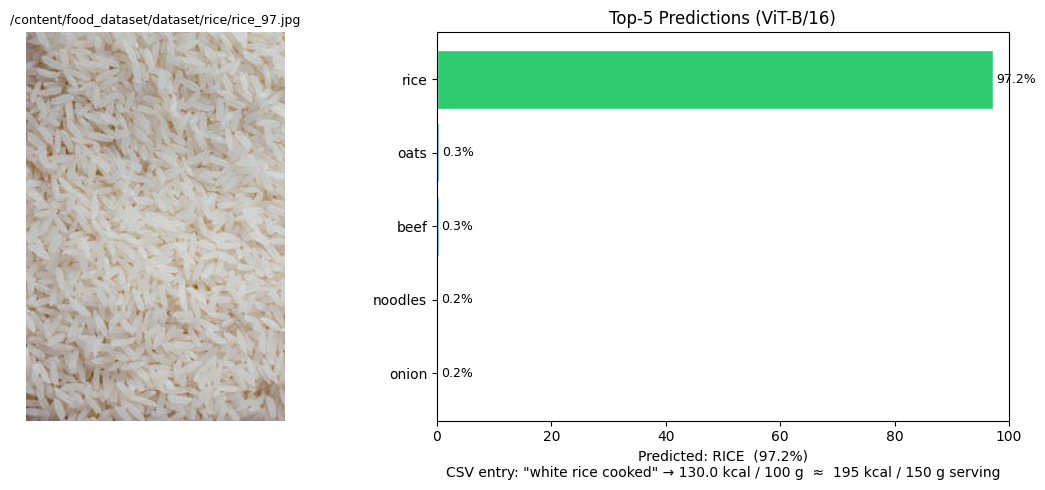

{
  "predicted_class": "rice",
  "csv_matched_name": "white rice cooked",
  "confidence": 0.9723,
  "cal_per_100g": 130.0,
  "cal_per_150g": 195.0,
  "top_k": [
    [
      "rice",
      0.9723
    ],
    [
      "oats",
      0.0033
    ],
    [
      "beef",
      0.003
    ],
    [
      "noodles",
      0.002
    ],
    [
      "onion",
      0.0017
    ]
  ]
}



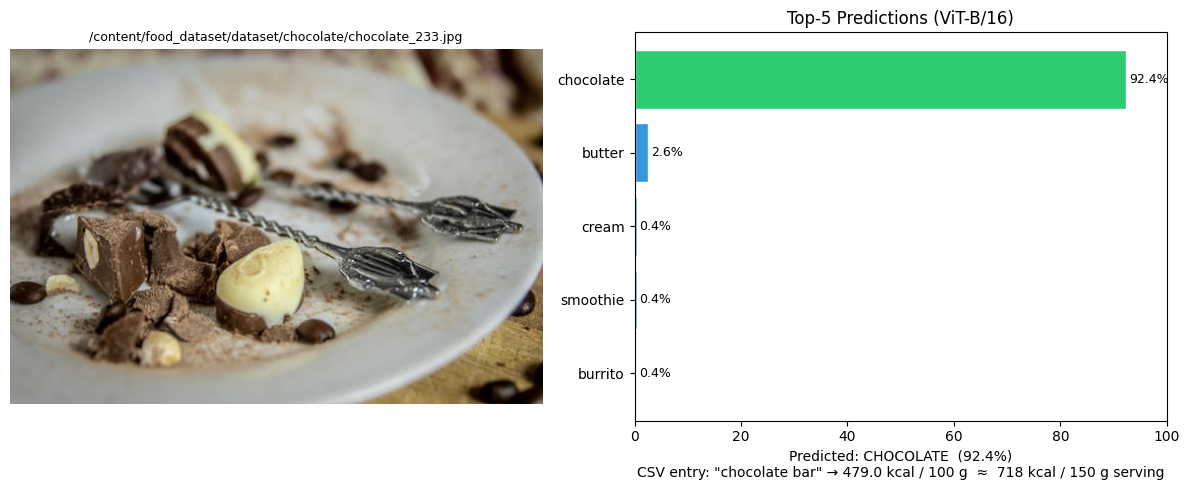

{
  "predicted_class": "chocolate",
  "csv_matched_name": "chocolate bar",
  "confidence": 0.9235,
  "cal_per_100g": 479.0,
  "cal_per_150g": 718.5,
  "top_k": [
    [
      "chocolate",
      0.9235
    ],
    [
      "butter",
      0.0262
    ],
    [
      "cream",
      0.0041
    ],
    [
      "smoothie",
      0.004
    ],
    [
      "burrito",
      0.0035
    ]
  ]
}



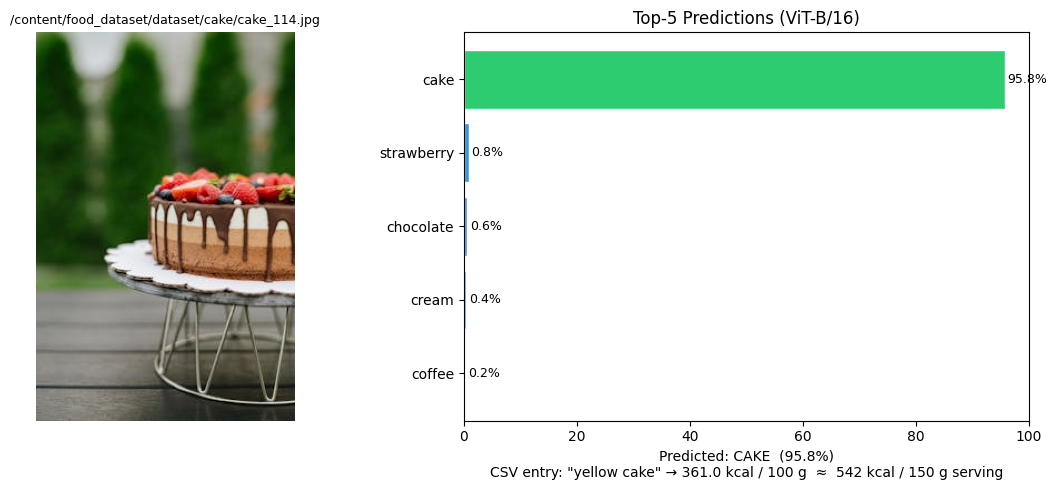

{
  "predicted_class": "cake",
  "csv_matched_name": "yellow cake",
  "confidence": 0.9578,
  "cal_per_100g": 361.0,
  "cal_per_150g": 541.5,
  "top_k": [
    [
      "cake",
      0.9578
    ],
    [
      "strawberry",
      0.0082
    ],
    [
      "chocolate",
      0.0061
    ],
    [
      "cream",
      0.0042
    ],
    [
      "coffee",
      0.0023
    ]
  ]
}



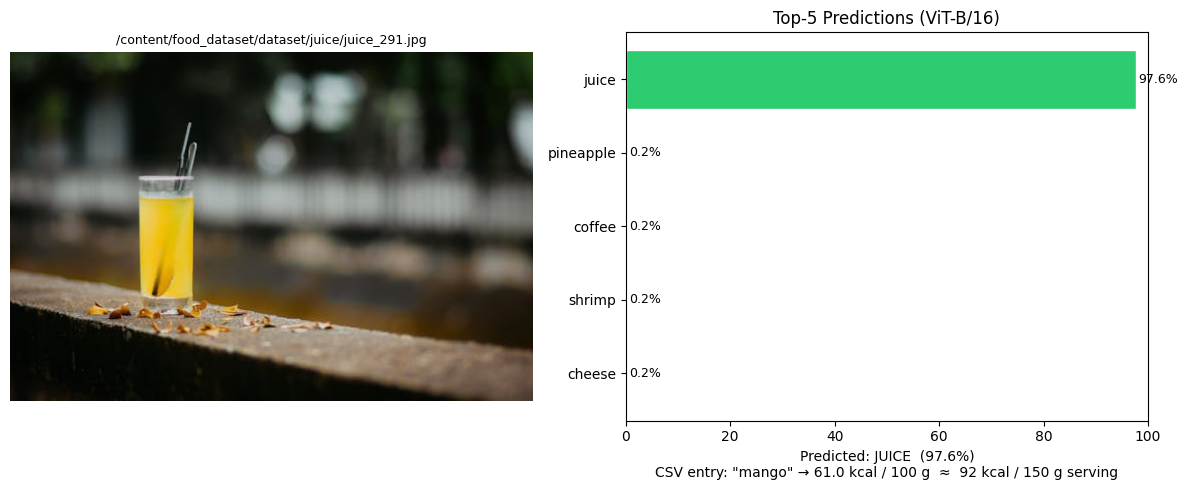

{
  "predicted_class": "juice",
  "csv_matched_name": "mango",
  "confidence": 0.9765,
  "cal_per_100g": 61.0,
  "cal_per_150g": 91.5,
  "top_k": [
    [
      "juice",
      0.9765
    ],
    [
      "pineapple",
      0.002
    ],
    [
      "coffee",
      0.002
    ],
    [
      "shrimp",
      0.0018
    ],
    [
      "cheese",
      0.0015
    ]
  ]
}



In [ ]:
sample_paths = []
for cls in random.sample(classes, 6):
    imgs = list((DATA_ROOT / cls).glob('*.*'))
    if imgs:
        sample_paths.append(str(random.choice(imgs)))

for path in sample_paths:
    result = predict_calories(path, top_k=5, serving_g=150)
    print(json.dumps(result, indent=2))
    print()

## 12 — Save / Load the Model

In [ ]:
# Saved directly to Drive so it survives Colab session resets
SAVE_PATH = str(DRIVE_ROOT / 'food_calorie_vit_b16.pth')

torch.save({
    'model_state_dict': model.state_dict(),
    'class_names':      CLASS_NAMES,
    'calorie_table':    CALORIE_TABLE,
    'num_classes':      NUM_CLASSES,
    'best_val_acc':     best_val_acc,
}, SAVE_PATH)
print(f'Model saved → {SAVE_PATH}')


def load_model(checkpoint_path: str):
    ckpt = torch.load(checkpoint_path, map_location=DEVICE)
    m = timm.create_model(
        'vit_base_patch16_224.augreg21k_ft_in1k',
        pretrained=False,
        num_classes=ckpt['num_classes']
    )
    m.load_state_dict(ckpt['model_state_dict'])
    m.to(DEVICE).eval()
    return m, ckpt['class_names'], ckpt['calorie_table']

# To reload: model, CLASS_NAMES, CALORIE_TABLE = load_model(SAVE_PATH)

Model saved → /content/drive/MyDrive/food_calorie_vit_b16.pth


## 13 — Predict on Your Own Image

In [ ]:
def predict_food_info(image_path):

    model.eval()

    img = Image.open(image_path).convert("RGB")

    x = val_tf(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():

        outputs = model(x)

        probs = torch.softmax(outputs.logits, dim=1)

        pred_idx = probs.argmax(dim=1).item()

        confidence = probs.max().item()

    predicted_class = classes[pred_idx]

    print("Predicted Food:", predicted_class)

    print("Confidence:", round(confidence * 100, 2), "%")

    matched_rows = df[
        df["matched_name"].str.lower() == predicted_class.lower()
    ]

    if len(matched_rows) > 0:

        row = matched_rows.iloc[0]

        print("\nFood Information")
        print("-------------------")

        print("Category :", row["category"])
        print("Portion  :", row["portion"])
        print("Calories :", row["calories"])
        print("Protein  :", row["protein"])
        print("Fat      :", row["fat"])
        print("Carb     :", row["carb"])

    else:

        print("\nNo nutrition data found in CSV.")

    plt.figure(figsize=(4,4))

    plt.imshow(img)

    plt.title(predicted_class)

    plt.axis("off")

    plt.show()

In [ ]:
torch.save(model.state_dict(), "best_vit_model.pth")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving pizza_39.jpg to pizza_39 (1).jpg


In [ ]:
MY_IMAGE = list(uploaded.keys())[0]

print(MY_IMAGE)

pizza_39 (1).jpg


In [ ]:
# Option A: image already in Drive
MY_IMAGE = '/content/drive/MyDrive/your_food_image.jpg'

# Option B: upload directly to Colab
# from google.colab import files
# uploaded = files.upload()
# MY_IMAGE = list(uploaded.keys())[0]

if os.path.exists(MY_IMAGE):
    result = predict_calories(MY_IMAGE, top_k=5, serving_g=200)
    print(json.dumps(result, indent=2))
    visualise_attention(MY_IMAGE)
else:
    print('⚠️  File not found — update MY_IMAGE path or use Option B above.')

⚠️  File not found — update MY_IMAGE path or use Option B above.
